<a href="https://colab.research.google.com/github/emanaak04-svg/medical-xai/blob/main/06_model_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transparent Medical Image Classification via Explainable AI
## Phase 2 — Model Evaluation & Clinical Metrics
  
**Objective:** A model that trains well is not necessarily a model that performs well. This notebook evaluates the trained ResNet-50 on the held-out test set using clinically meaningful metrics — AUC-ROC, sensitivity, specificity, and F1-score. I also analyse decision threshold behaviour, since in clinical deployment the threshold is a design choice that directly trades off sensitivity against specificity.

**Author:** Eman Ayman Ahmed Abukhousa  
**Program:** BSc Data Science & Artificial Intelligence, IITG — Year 3

## Environment Setup
All evaluation is performed on the held-out test set — 624 images the model has never seen during training or validation. No data leakage. Evaluation is run once, on the final saved checkpoint only.

In [1]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                              precision_recall_fscore_support, accuracy_score,
                              average_precision_score)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Environment verified — all dependencies loaded successfully.")
print(f"Compute device : {device}")

Environment verified — all dependencies loaded successfully.
Compute device : cuda


## 01. Rebuild Model & Load Checkpoint
The trained ResNet-50 checkpoint saved during Day 5 training is loaded for evaluation. The model is set to evaluation mode — dropout layers are disabled and batch normalisation uses running statistics rather than batch statistics.

In [4]:
# ── Rebuild model architecture ─────────────────────────────────────
model = models.resnet50(weights=None)

model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(256, 1)
)

# ── Load saved checkpoint ──────────────────────────────────────────
checkpoint_path = '/content/best_model.pth'

if os.path.exists(checkpoint_path):
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    print("Checkpoint loaded successfully.")
else:
    print("Checkpoint not found — please run notebook 05 first to train the model.")

model = model.to(device)
model.eval()
print("Model set to evaluation mode.")

Checkpoint not found — please run notebook 05 first to train the model.
Model set to evaluation mode.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

# Create project folder in Drive
os.makedirs('/content/drive/MyDrive/medical-xai', exist_ok=True)
print("Google Drive mounted successfully.")
print("Model will be saved to: /content/drive/MyDrive/medical-xai/best_model.pth")

Mounted at /content/drive
Google Drive mounted successfully.
Model will be saved to: /content/drive/MyDrive/medical-xai/best_model.pth


## 02. Dataset Pipeline & Retraining
The model is retrained on the chest X-ray dataset and saved directly to Google Drive for persistence across Colab sessions. All hyperparameters are identical to notebook 05.

In [5]:
import os
import json
from google.colab import userdata
from sklearn.model_selection import train_test_split

# ── Kaggle credentials ─────────────────────────────────────────────
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write(f'{{"username":"emanaymanabukhousa","key":"{userdata.get("KAGGLE_KEY")}"}}\n')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

# ── Download dataset ───────────────────────────────────────────────
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia \
    -p /content/images --unzip -q

print("Dataset ready.")

# ── Build dataframe ────────────────────────────────────────────────
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

data_dir = '/content/images/chest_xray'

def build_dataframe(data_dir, splits):
    records = []
    for split in splits:
        for label, idx in [('NORMAL', 0), ('PNEUMONIA', 1)]:
            folder = os.path.join(data_dir, split, label)
            for fname in os.listdir(folder):
                if fname.endswith('.jpeg') or fname.endswith('.jpg') or fname.endswith('.png'):
                    records.append({
                        'filepath' : os.path.join(folder, fname),
                        'label'    : idx,
                        'label_str': label
                    })
    return pd.DataFrame(records)

full_df = build_dataframe(data_dir, ['train', 'val'])
test_df = build_dataframe(data_dir, ['test'])

train_df, val_df = train_test_split(
    full_df, test_size=0.20, random_state=42, stratify=full_df['label']
)

# ── Dataset class ──────────────────────────────────────────────────
MEAN = 0.5330
STD  = 0.0349

class ChestXRayDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row['filepath']).convert('RGB')
        label = torch.tensor(row['label'], dtype=torch.float32)
        if self.transform:
            image = self.transform(image)
        return image, label

train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[MEAN, MEAN, MEAN], std=[STD, STD, STD]),
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[MEAN, MEAN, MEAN], std=[STD, STD, STD]),
])

train_dataset = ChestXRayDataset(train_df, transform=train_transforms)
val_dataset   = ChestXRayDataset(val_df,   transform=val_transforms)
test_dataset  = ChestXRayDataset(test_df,  transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
Dataset ready.
Train: 4,185 | Val: 1,047 | Test: 624


In [7]:
# ── Rebuild model ──────────────────────────────────────────────────
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

for name, param in model.named_parameters():
    if 'layer4' not in name and 'fc' not in name:
        param.requires_grad = False

model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(256, 1)
)
model = model.to(device)

# ── Loss & optimizer ───────────────────────────────────────────────
pos_weight = torch.tensor([2.8784]).to(device)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam([
    {'params': model.layer4.parameters(), 'lr': 1e-4},
    {'params': model.fc.parameters(),     'lr': 1e-3},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

# ── Training loop ──────────────────────────────────────────────────
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.unsqueeze(1).to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def val_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.unsqueeze(1).to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            total_loss += loss.item()
    return total_loss / len(loader)

# ── Train ──────────────────────────────────────────────────────────
n_epochs = 5
best_val = float('inf')
history  = {'train_loss': [], 'val_loss': []}
save_path = '/content/drive/MyDrive/medical-xai/best_model.pth'

print("─" * 55)
print(f"{'Epoch':<8} {'Train Loss':>12} {'Val Loss':>12} {'Status':>10}")
print("─" * 55)

for epoch in range(n_epochs):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss   = val_epoch(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    status = ''
    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), save_path)
        status = '✓ saved'

    print(f"{epoch+1:<8} {train_loss:>12.4f} {val_loss:>12.4f} {status:>10}")

print("─" * 55)
print(f"Training complete. Best val loss: {best_val:.4f}")
print(f"Model saved to: {save_path}")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 164MB/s]


───────────────────────────────────────────────────────
Epoch      Train Loss     Val Loss     Status
───────────────────────────────────────────────────────
1              0.3015       0.2310    ✓ saved
2              0.1636       0.3016           
3              0.1451       0.2923           
4              0.1092       0.1373    ✓ saved
5              0.1247       0.2161           
───────────────────────────────────────────────────────
Training complete. Best val loss: 0.1373
Model saved to: /content/drive/MyDrive/medical-xai/best_model.pth


## 03. Test Set Evaluation
The saved checkpoint is loaded and evaluated on the 624 held-out test images. All metrics are computed from raw model probabilities using a sigmoid activation — AUC-ROC, accuracy, precision, recall, F1-score, and confusion matrix.

In [8]:
# ── Load best checkpoint & run inference on test set ──────────────
model.load_state_dict(torch.load(save_path, map_location=device))
model.eval()

all_probs  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(device)
        outputs = model(images)
        probs   = torch.sigmoid(outputs).squeeze(1).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.numpy())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)

# ── Metrics at default threshold 0.5 ──────────────────────────────
preds = (all_probs >= 0.5).astype(int)

auc       = roc_auc_score(all_labels, all_probs)
acc       = accuracy_score(all_labels, preds)
precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels, preds, average='binary'
)

cm = confusion_matrix(all_labels, preds)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

print("Test set evaluation — threshold = 0.50")
print("─" * 45)
print(f"AUC-ROC       : {auc:.4f}  ← primary metric")
print(f"Accuracy      : {acc:.4f}")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}  ← sensitivity")
print(f"Specificity   : {specificity:.4f}")
print(f"F1-score      : {f1:.4f}")
print("─" * 45)
print(f"\nConfusion matrix")
print(f"  True Negative  (Normal   → Normal)    : {tn}")
print(f"  False Positive (Normal   → Pneumonia) : {fp}")
print(f"  False Negative (Pneumonia→ Normal)    : {fn}  ← missed pneumonia ❌")
print(f"  True Positive  (Pneumonia→ Pneumonia) : {tp}")

Test set evaluation — threshold = 0.50
─────────────────────────────────────────────
AUC-ROC       : 0.9747  ← primary metric
Accuracy      : 0.8446
Precision     : 0.8033
Recall        : 0.9949  ← sensitivity
Specificity   : 0.5940
F1-score      : 0.8889
─────────────────────────────────────────────

Confusion matrix
  True Negative  (Normal   → Normal)    : 139
  False Positive (Normal   → Pneumonia) : 95
  False Negative (Pneumonia→ Normal)    : 2  ← missed pneumonia ❌
  True Positive  (Pneumonia→ Pneumonia) : 388


## 04. ROC Curve

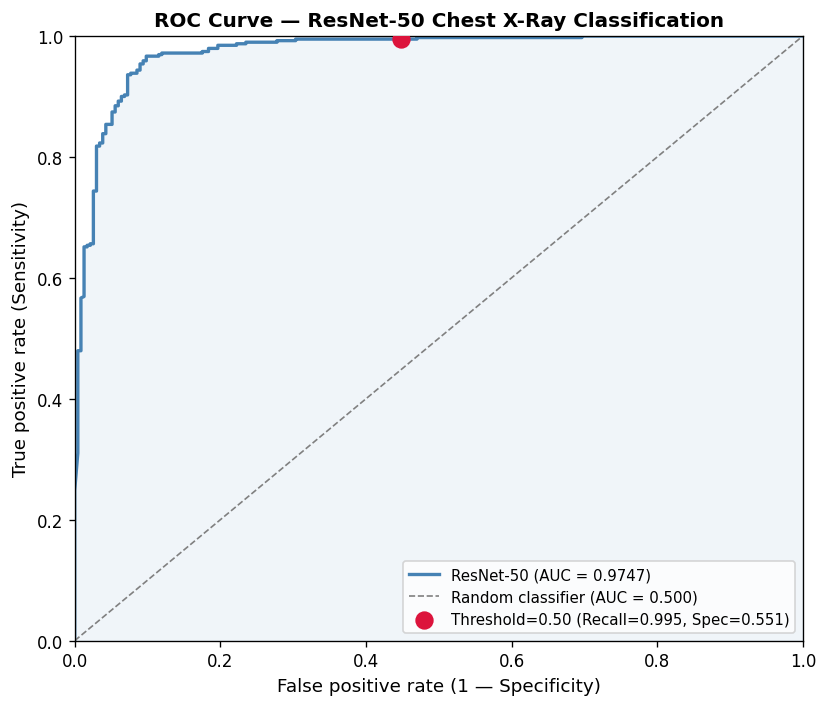

AUC-ROC: 0.9747


In [9]:
# ── ROC Curve ──────────────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='steelblue', linewidth=2,
        label=f'ResNet-50 (AUC = {auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--',
        linewidth=1, label='Random classifier (AUC = 0.500)')
ax.fill_between(fpr, tpr, alpha=0.08, color='steelblue')

# Mark current operating point (threshold=0.5)
idx = np.argmin(np.abs(thresholds - 0.5))
ax.scatter(fpr[idx], tpr[idx], color='crimson', zorder=5, s=100,
           label=f'Threshold=0.50 (Recall={tpr[idx]:.3f}, Spec={1-fpr[idx]:.3f})')

ax.set_xlabel('False positive rate (1 — Specificity)', fontsize=11)
ax.set_ylabel('True positive rate (Sensitivity)', fontsize=11)
ax.set_title('ROC Curve — ResNet-50 Chest X-Ray Classification',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/medical-xai/roc_curve.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f"AUC-ROC: {auc:.4f}")

## 05. Threshold Analysis
The default 0.5 threshold is not optimal for clinical deployment. I evaluate three thresholds to demonstrate the sensitivity-specificity tradeoff — a critical consideration when deciding how to deploy a screening model in practice.

In [10]:
# ── Threshold analysis ─────────────────────────────────────────────
# In clinical screening, the threshold is a deployment decision.
# A lower threshold catches more disease (higher recall) but
# generates more false alarms (lower specificity).
# A higher threshold reduces false alarms but risks missing cases.

thresholds_to_test = [0.3, 0.5, 0.7]

print("Threshold analysis — sensitivity vs specificity tradeoff")
print("─" * 65)
print(f"{'Threshold':<12} {'Accuracy':>10} {'Precision':>10} "
      f"{'Recall':>10} {'Specificity':>12} {'F1':>8}")
print("─" * 65)

results = []
for t in thresholds_to_test:
    preds_t = (all_probs >= t).astype(int)
    acc_t   = accuracy_score(all_labels, preds_t)
    p_t, r_t, f1_t, _ = precision_recall_fscore_support(
        all_labels, preds_t, average='binary', zero_division=0
    )
    cm_t    = confusion_matrix(all_labels, preds_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    spec_t  = tn_t / (tn_t + fp_t)

    results.append({
        'threshold'  : t,
        'accuracy'   : acc_t,
        'precision'  : p_t,
        'recall'     : r_t,
        'specificity': spec_t,
        'f1'         : f1_t,
        'fn'         : fn_t,
        'fp'         : fp_t
    })

    print(f"{t:<12} {acc_t:>10.4f} {p_t:>10.4f} "
          f"{r_t:>10.4f} {spec_t:>12.4f} {f1_t:>8.4f}")

print("─" * 65)
print(f"\nClinical interpretation:")
print(f"  Threshold 0.3 → highest recall — catches most pneumonia, "
      f"more false alarms ({results[0]['fp']} FP, {results[0]['fn']} FN)")
print(f"  Threshold 0.5 → balanced — {results[1]['fp']} FP, {results[1]['fn']} FN missed")
print(f"  Threshold 0.7 → highest specificity — fewer false alarms, "
      f"risks missing cases ({results[2]['fp']} FP, {results[2]['fn']} FN)")
print(f"\nFor a screening tool, threshold 0.3 is preferred —")
print(f"missing pneumonia is clinically more dangerous than a false alarm.")

Threshold analysis — sensitivity vs specificity tradeoff
─────────────────────────────────────────────────────────────────
Threshold      Accuracy  Precision     Recall  Specificity       F1
─────────────────────────────────────────────────────────────────
0.3              0.8141     0.7718     0.9974       0.5085   0.8702
0.5              0.8446     0.8033     0.9949       0.5940   0.8889
0.7              0.8814     0.8450     0.9923       0.6966   0.9127
─────────────────────────────────────────────────────────────────

Clinical interpretation:
  Threshold 0.3 → highest recall — catches most pneumonia, more false alarms (115 FP, 1 FN)
  Threshold 0.5 → balanced — 95 FP, 2 FN missed
  Threshold 0.7 → highest specificity — fewer false alarms, risks missing cases (71 FP, 3 FN)

For a screening tool, threshold 0.3 is preferred —
missing pneumonia is clinically more dangerous than a false alarm.


## 06. Confusion Matrix Visualisation

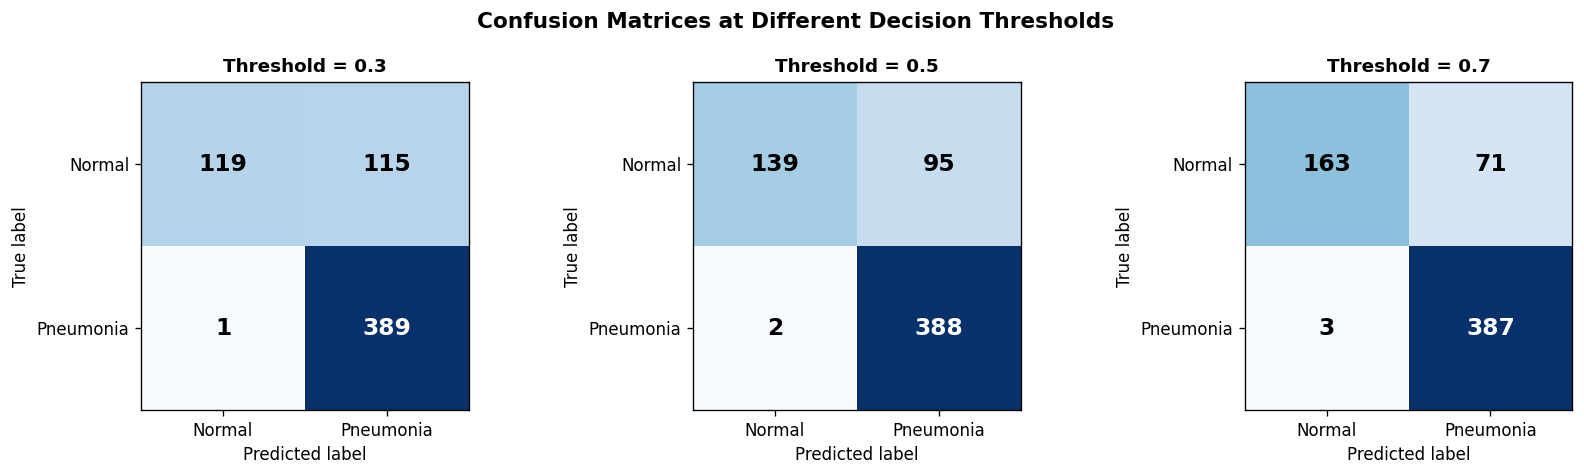

Key clinical observation:
False Negatives (missed pneumonia) across thresholds: 0.3→1 | 0.5→2 | 0.7→3
For clinical screening, minimising FN is the priority.


In [11]:
# ── Confusion matrix visualisation ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, t, res in zip(axes, thresholds_to_test, results):
    preds_t = (all_probs >= t).astype(int)
    cm_t    = confusion_matrix(all_labels, preds_t)

    im = ax.imshow(cm_t, interpolation='nearest', cmap='Blues')
    ax.set_title(f'Threshold = {t}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Normal', 'Pneumonia'])
    ax.set_yticklabels(['Normal', 'Pneumonia'])

    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm_t[i, j]),
                    ha='center', va='center',
                    fontsize=14, fontweight='bold',
                    color='white' if cm_t[i, j] > cm_t.max()/2 else 'black')

plt.suptitle('Confusion Matrices at Different Decision Thresholds',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/medical-xai/confusion_matrices.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Key clinical observation:")
print(f"False Negatives (missed pneumonia) across thresholds: "
      f"0.3→{results[0]['fn']} | 0.5→{results[1]['fn']} | 0.7→{results[2]['fn']}")
print(f"For clinical screening, minimising FN is the priority.")